In [15]:
import os
import math
import numpy as np
import torch
import pickle as pkl
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from pathlib import Path
from typing import Iterable

In [16]:
def fit_global_pca(history, key, max_samples=50000):
    mats = []
    for rec in history:
        m = to_matrix(rec[key])
        mats.append(m)

    big = np.concatenate(mats, axis=0)

    if len(big) > max_samples:
        idx = np.random.choice(len(big), max_samples, replace=False)
        big = big[idx]

    pca = PCA(n_components=2)
    pca.fit(big)
    return pca


def avg(iterator: Iterable[float|int]):
    t = 0
    sum = 0
    for item in iterator:
        sum += item
        t += 1

    return sum/t

In [3]:
def load_history(path: Path):
    files = os.listdir(path)

    history = []
    for file in files:
        with open(path / file, "rb") as f:
            history.append(pkl.load(f))
            
    return sort_by_round(history)

def sort_by_round(history):
    return sorted(history, key=lambda x: x["round"])

def to_matrix(list_of_vecs):
    """
    [K x d] list -> numpy array
    """
    if isinstance(list_of_vecs, np.ndarray):
        return list_of_vecs
    return np.stack(list_of_vecs)


def pca_2d(mat):
    pca = PCA(n_components=2)
    return pca.fit_transform(mat)


def make_grid(n):
    cols = math.ceil(math.sqrt(n))
    rows = math.ceil(n / cols)
    return rows, cols

def global_bounds(history, key, pca):
    xs, ys = [], []

    for rec in history:
        mat = to_matrix(rec[key])
        pts = pca.transform(mat)
        xs.append(pts[:, 0])
        ys.append(pts[:, 1])

    xs = np.concatenate(xs)
    ys = np.concatenate(ys)

    pad_x = 0.05 * (xs.max() - xs.min() + 1e-12)
    pad_y = 0.05 * (ys.max() - ys.min() + 1e-12)

    return (
        xs.min() - pad_x,
        xs.max() + pad_x,
        ys.min() - pad_y,
        ys.max() + pad_y,
    )


In [4]:
from typing import Literal

def plot_sheet(history, key: Literal['proj_updates', 'proj_weights']="proj_updates", save_path=None):
    n_rounds = len(history)

    # 1) fit once
    pca = fit_global_pca(history, key)

    # 2) freeze window
    xmin, xmax, ymin, ymax = global_bounds(history, key, pca)

    rows, cols = make_grid(n_rounds)
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for ax in axes[n_rounds:]:
        ax.axis("off")

    for i, rec in enumerate(history):
        ax = axes[i]
        mat = to_matrix(rec[key])
        pts = pca.transform(mat)

        ax.scatter(pts[:, 0], pts[:, 1], s=15)
        ax.set_title(f"Round {rec['round']}")

        # 🔒 locked camera
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)

        # show ticks
        ax.tick_params(axis="both", labelsize=6)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=200)
    else:
        plt.show()

In [5]:
os.getcwd()

'/home/skandabhairava/Desktop/MFT_FL/notebooks'

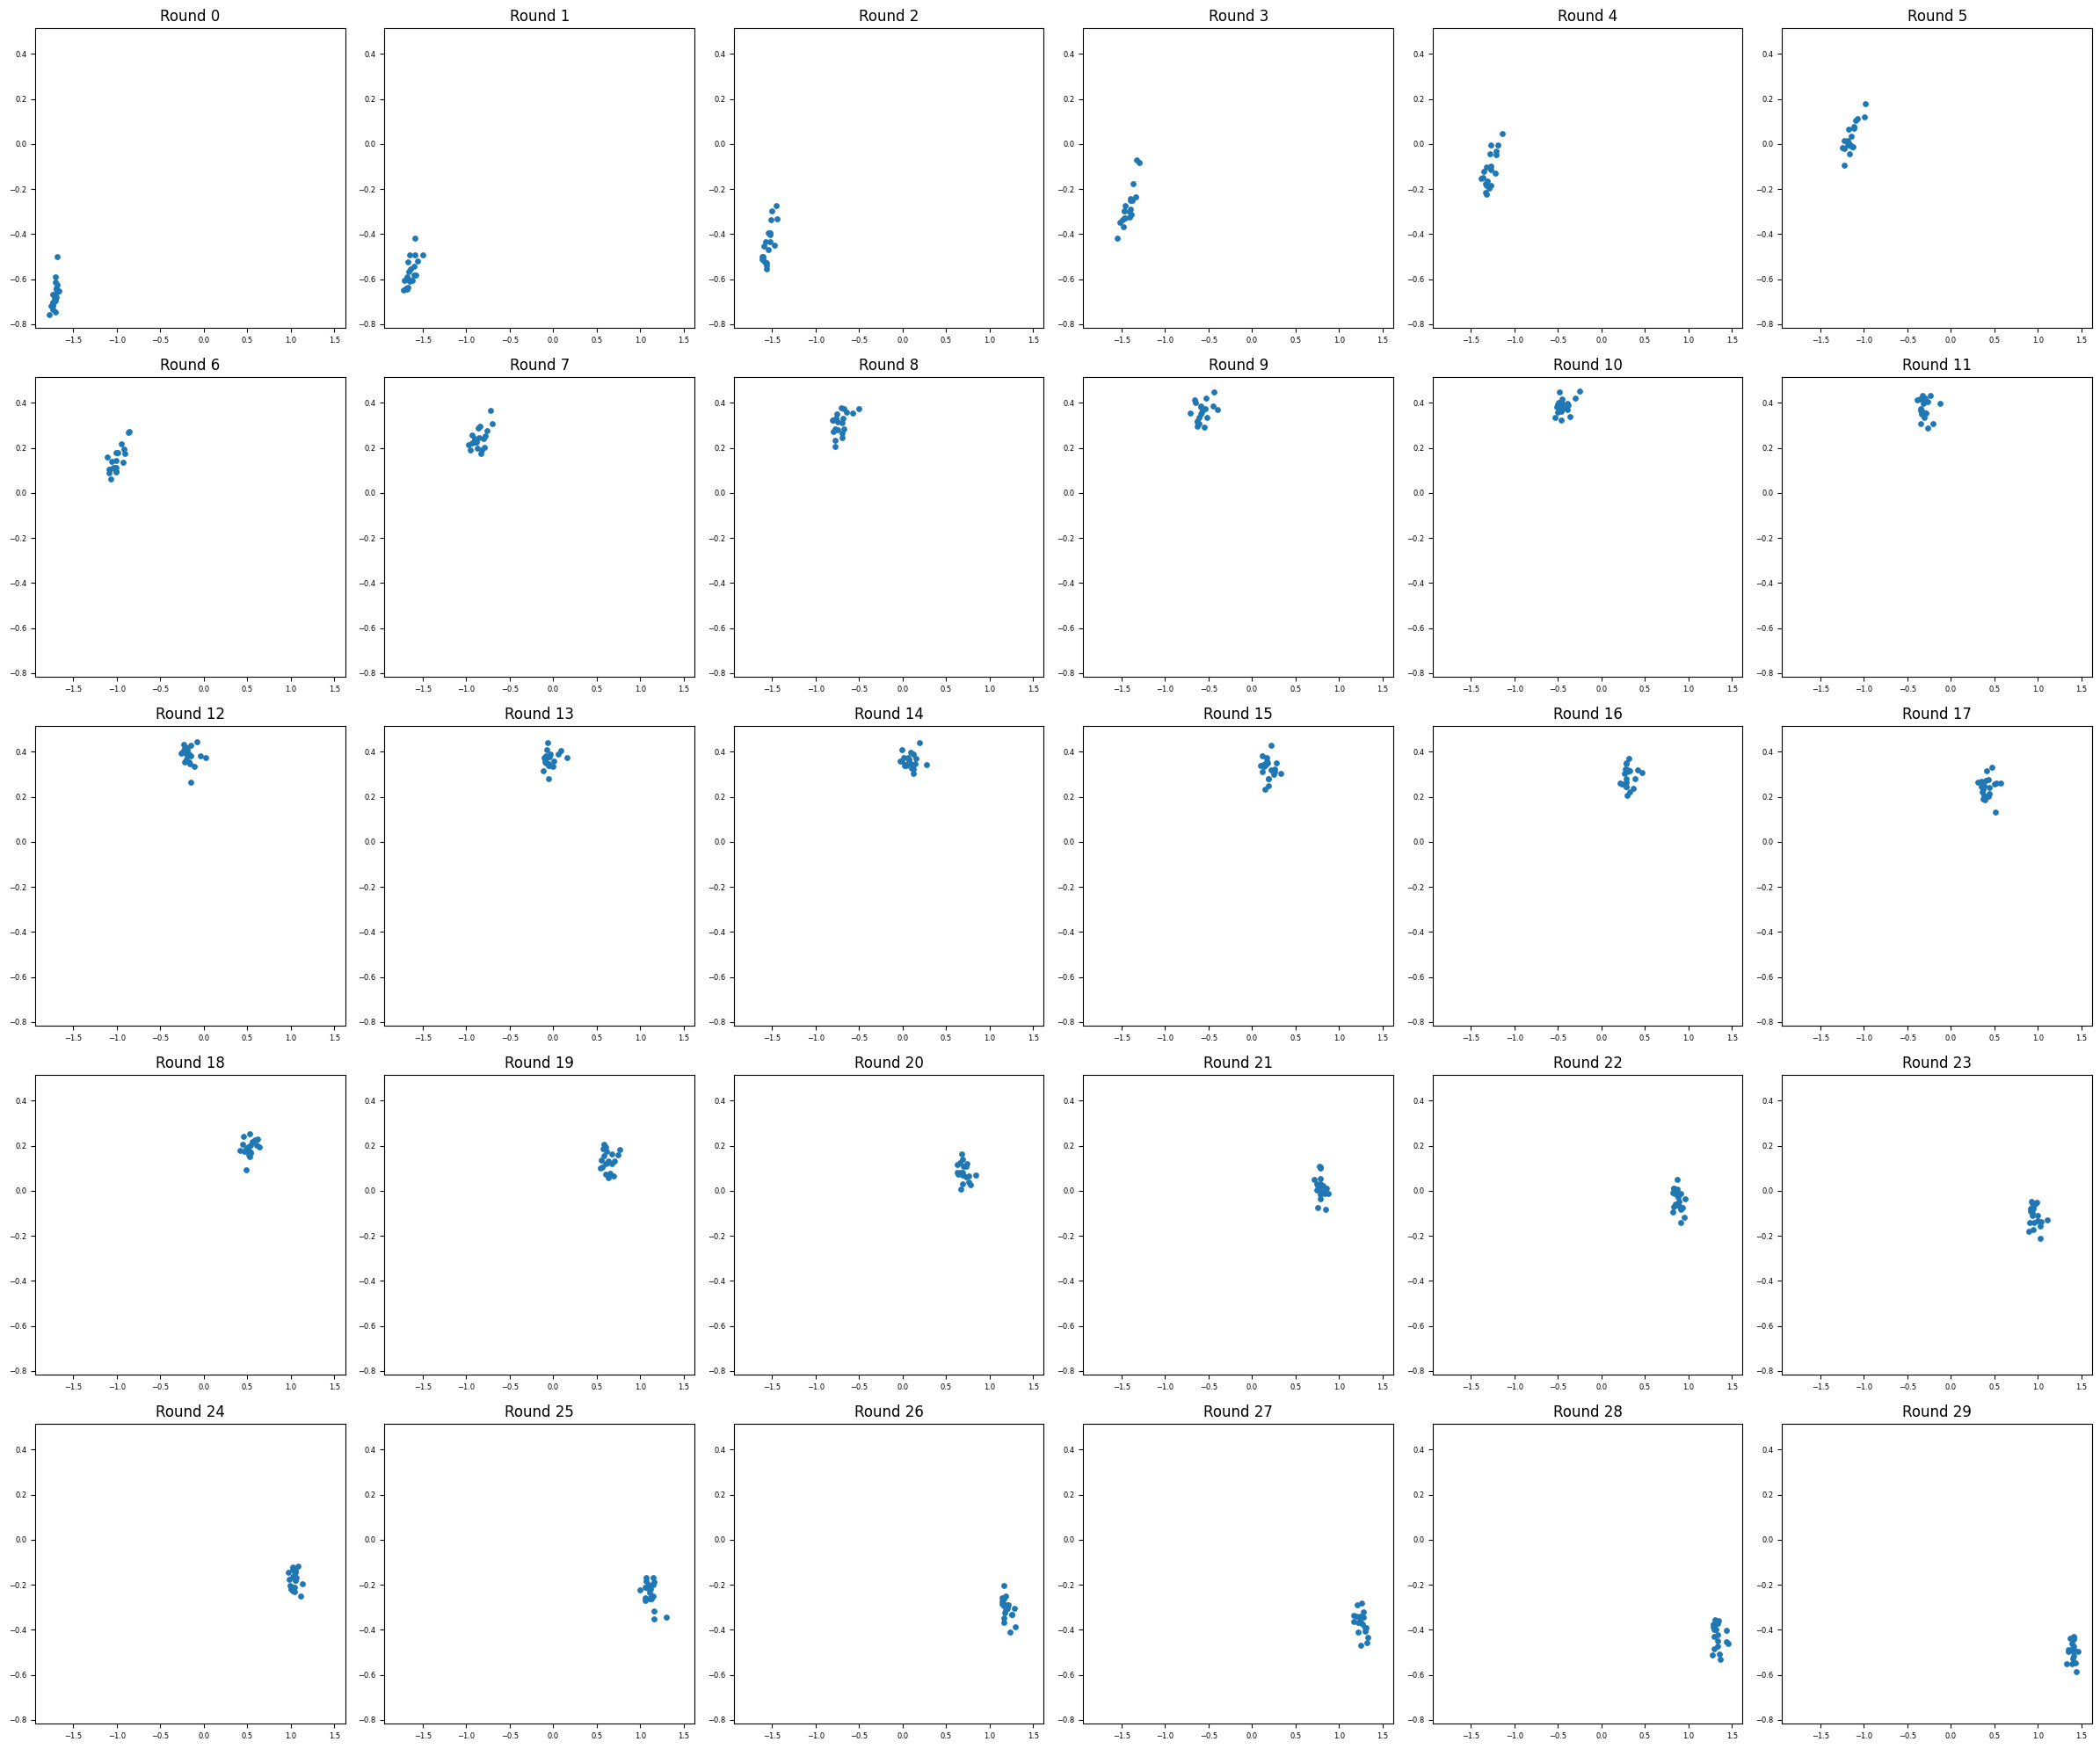

In [10]:
run_id = "RUN_Sun_Feb__8_20-29-08_2026"
history = load_history(Path("../logs") / run_id)
key = ('proj_updates', 'proj_weights')[1]
plot_sheet(history, key=key)

In [20]:
avg([rnd['stats']['var'] for rnd in history]), avg([rnd['stats']['mean_norm'] for rnd in history])

(9.800572205638976e-08, 0.18263620535532635)

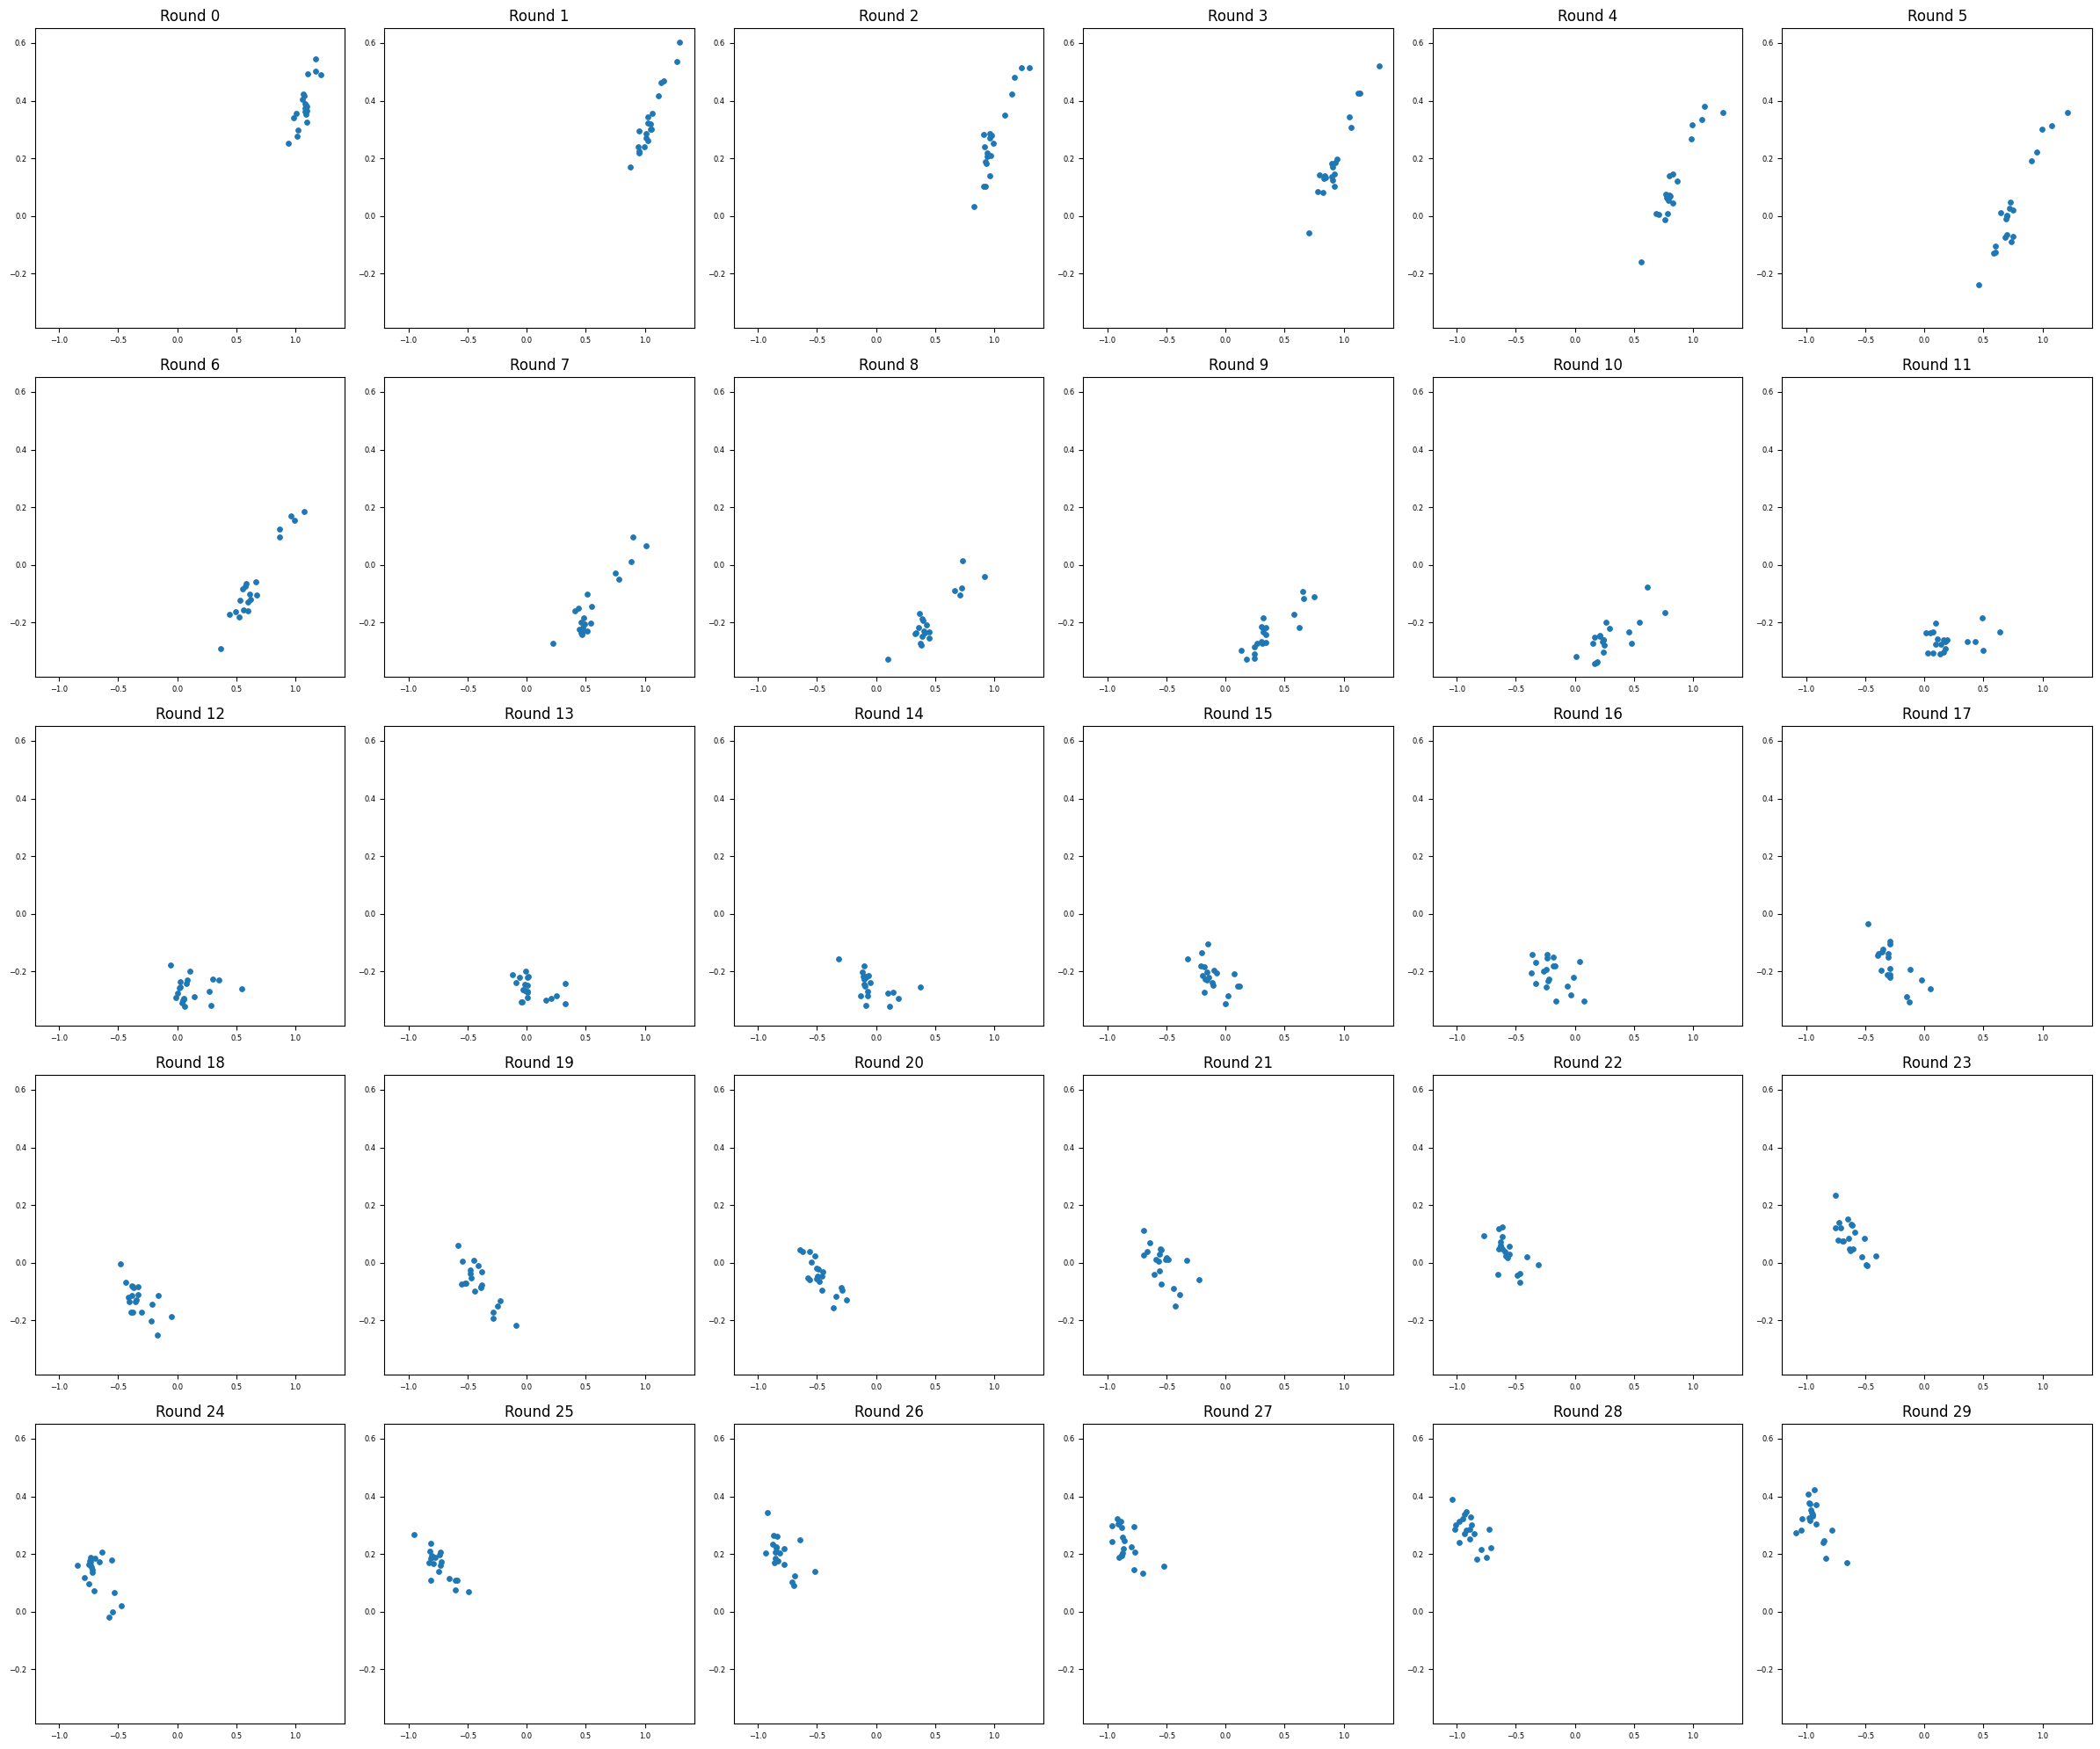

In [28]:
run_id = "RUN_Sun_Feb__8_23-09-49_2026_20_byzantine_flip"
history = load_history(Path("../logs") / run_id)
key = ('proj_updates', 'proj_weights')[1]
plot_sheet(history, key=key)

In [27]:
avg([rnd['stats']['var'] for rnd in history]), avg([rnd['stats']['mean_norm'] for rnd in history])

(1.0355627537705913e-07, 0.14251975218454996)

In [23]:
9.800572205638976e-08 < 1.0355627537705913e-07

True

In [25]:
0.18263620535532635 > 0.14251975218454996

True